In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv('netflix_titles.csv')

In [3]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


***1.Data Exploration***

In [4]:
df.shape

(8807, 12)

**Data has 8807 rows and 12 columns**

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

- **show_id** → Unique identifier for each record  
- **type** → Indicates whether content is a Movie or TV Show  
- **title** → Name of the show/movie  
- **director** → Director name(s)  
- **cast** → List of actors/actresses  
- **country** → Country of production  
- **date_added** → Date when content was added to Netflix  
- **release_year** → Year of release (numerical)  
- **rating** → Age rating (e.g., PG, TV-MA)  
- **duration** → Duration in minutes or number of seasons  
- **listed_in** → Genre/category of the content  
- **description** → Brief summary of the content

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


- The dataset contains **8,807 entries and 12 columns**, with most features being categorical in nature.  
- Missing values are present mainly in **director, cast, and country columns**, which need to be handled during data cleaning.  
- Only **one numerical column (release_year)** is present, while the rest are **text-based features** used for categorical analysis.

***2.Data Cleaning***

In [7]:
#missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.isnull().sum()[df.isnull().sum()>0]

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

In [10]:
#director
df['director'].fillna('Unknown', inplace=True)

In [12]:
#cast
df['cast'].fillna('Not Available',inplace=True)

In [14]:
#country
df['country'].fillna('Unknown',inplace=True)

In [16]:
#date_added
df['date_added'].fillna('Unknown', inplace=True)

In [18]:
#rating
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

In [20]:
#duration
df['duration'].fillna('0 min', inplace=True)

In [21]:
#duplicacy
print("No.of duplicate enteries",df.duplicated().sum())

No.of duplicate enteries 0


In [22]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [23]:
df.date_added

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [24]:
df['year_added'] = df['date_added'].dt.year

In [25]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

In [26]:
df.duration

0          90 min
1       2 Seasons
2        1 Season
3        1 Season
4       2 Seasons
          ...    
8802      158 min
8803    2 Seasons
8804       88 min
8805       88 min
8806      111 min
Name: duration, Length: 8807, dtype: object

In [38]:
df[['duration_value','duration_unit']]=df['duration'].str.split(' ',expand=True)

In [40]:
df['duration_unit']=df['duration_unit'].str.replace('Seasons','Season')
df['duration_value']=df['duration_value'].astype(int)

In [41]:
df.drop(columns=['duration'],inplace=True)

In [42]:
df[df['type']=='Movie']['duration_value'].mean()

np.float64(99.52846191485891)

In [45]:
df[df['type']=='TV SHOW']['duration_value'].value_counts
df[df['type']=='Movie']['duration_value'].value_counts()

duration_value
90     152
94     146
93     146
97     146
91     144
      ... 
16       1
8        1
9        1
208      1
191      1
Name: count, Length: 206, dtype: int64

In [29]:
df['country'] = df['country'].str.strip()

In [30]:
df['listed_in'] = df['listed_in'].str.strip()

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
 13  duration_num  8807 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 963.4+ KB


In [32]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
duration_num     0
dtype: int64

In [33]:
df=df.dropna(subset=["date_added"])

In [34]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
duration_num    0
dtype: int64

***3.Descriptive Statistics***

In [35]:
df.describe()

,date_added,release_year,year_added,duration_num
count,8709,8709.000000,8709.000000,8709.000000
mean,2019-05-23 01:45:29.452290816,2014.197038,2018.887932,70.566311
min,2008-01-01 00:00:00,1925.000000,2008.000000,0.000000
25%,2018-04-20 00:00:00,2013.000000,2018.000000,2.000000
50%,2019-07-12 00:00:00,2017.000000,2019.000000,89.000000
75%,2020-08-26 00:00:00,2019.000000,2020.000000,106.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,312.000000
std,NaN,8.826219,1.567961,50.618985


- Dataset contains *8709 records*
- Most content was released around *2014*
- Majority of content was added to Netflix during *2018–2019*
- Content ranges from *1925 to 2021*
- Average content duration is around *70 minutes*
- Most content duration is *below 106 minutes*
- Duration shows *high variation across content*

***4.Data Visulalization Part-1***

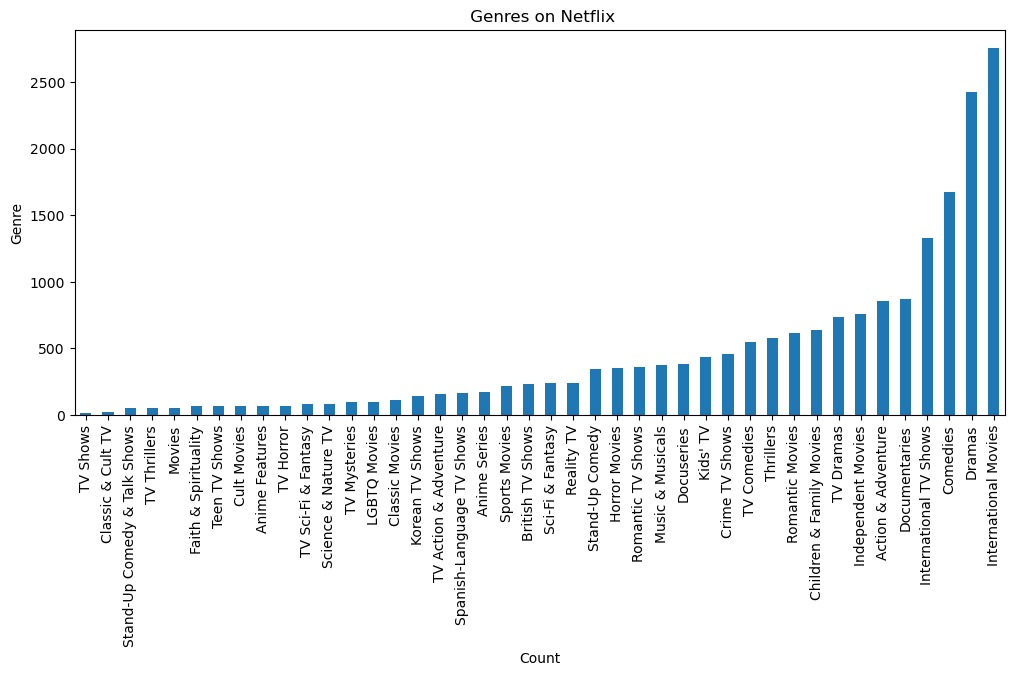

In [36]:
plt.figure(figsize=(12,5))
genre_counts = df['listed_in'].str.split(', ').explode().value_counts()
genre_counts.sort_values().plot(kind='bar')
plt.title(" Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

- Wide variety of genres available on Netflix  
- International Movies have the highest count  
- Dramas, Comedies, and Documentaries are highly popular  
- Movies are more common than TV Shows  
- Some genres have very low counts   
- Distribution is right-skewed  
- Focus is on popular genres with some niche categories  

***5.Data Visualization Part-2***

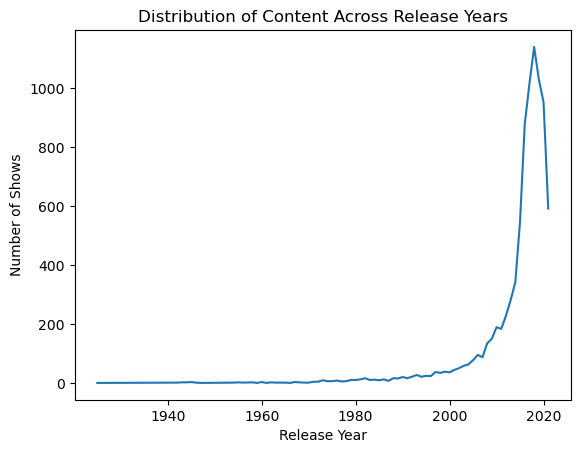

In [54]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts.plot()
plt.title("Distribution of Content Across Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.show()

- Content count increases gradually over the years  
- Very low number of shows before 2000  
- Rapid growth observed after 2010  
- Peak content release around recent years (2020 approx.)  
- Sudden drop in the latest year (possibly incomplete data)  
- Trend shows Netflix expanded content heavily in recent years  
- Overall upward trend in content production  

***6.Data Visualizations Part-3***

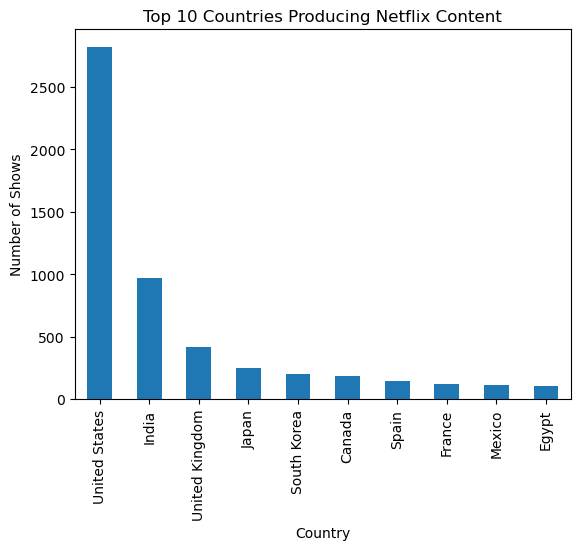

In [32]:
country_counts = df['country'].value_counts().head(10)
country_counts.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.show()

- United States produces the highest number of Netflix content  
- India is the second-largest content producer  
- "Unknown" category also has a significant count  
- United Kingdom contributes a moderate number of shows  
- Japan and South Korea have notable contributions  
- Other countries like Canada, Spain, France, and Mexico have lower counts  
- Content production is dominated by a few countries  

***7.Time Series Analysis***

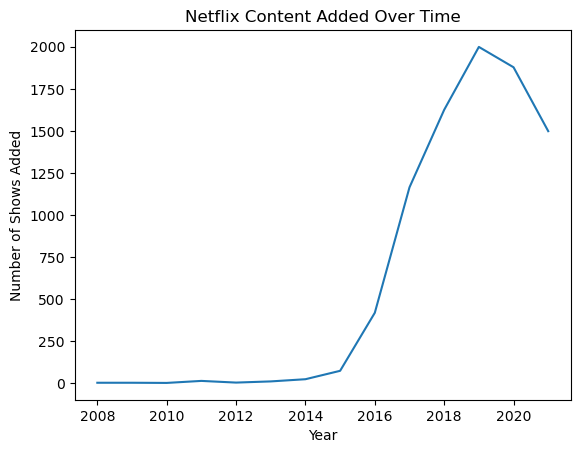

In [56]:
time_series = df.groupby('year_added').size()
time_series.plot()
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Shows Added")
plt.show()

- Number of shows added increases over time  
- Very slow growth before 2015  
- Sharp rise in content addition after 2016  
- Peak addition observed around 2019  
- Slight decline after peak years  
- Indicates rapid expansion phase of Netflix  
- Overall strong upward trend in content addition  

***8.Content Analysis Part-1***

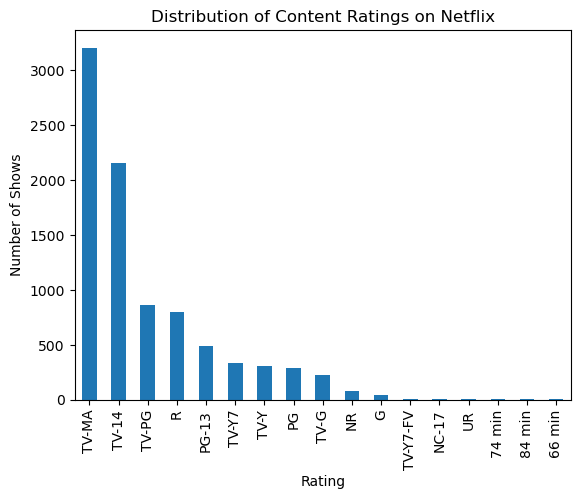

In [33]:
rating_counts = df['rating'].value_counts()
rating_counts.plot(kind='bar')
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Shows")
plt.show()

- TV-MA has the highest number of shows  
- TV-14 is the second most common rating  
- Majority of content is for mature audiences  
- Ratings like TV-PG and R have moderate counts  
- Kids content (G, TV-Y, TV-Y7) is comparatively lower  
- Very few shows fall under rare ratings (NC-17, TV-Y7-FV)  
- Indicates focus on adult and teenage audience  

***9.Content Analysis Part-2***

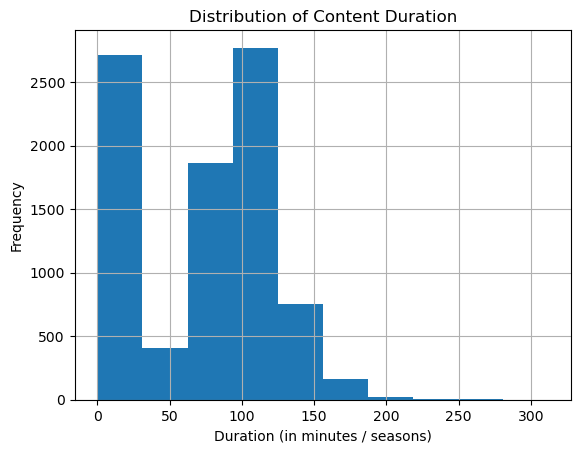

In [58]:
df['duration_num'].hist()
plt.title("Distribution of Content Duration")
plt.xlabel("Duration (in minutes / seasons)")
plt.ylabel("Frequency")
plt.show()

- Most content falls within shorter to medium duration  
- Peak concentration around 80–120 minutes  
- Few contents have very long duration  
- Distribution is slightly right-skewed  
- Majority of movies are around typical movie length  
- Very short and very long durations are less common  
- Indicates preference for standard-length content  

***10.Top List and Recommendations***

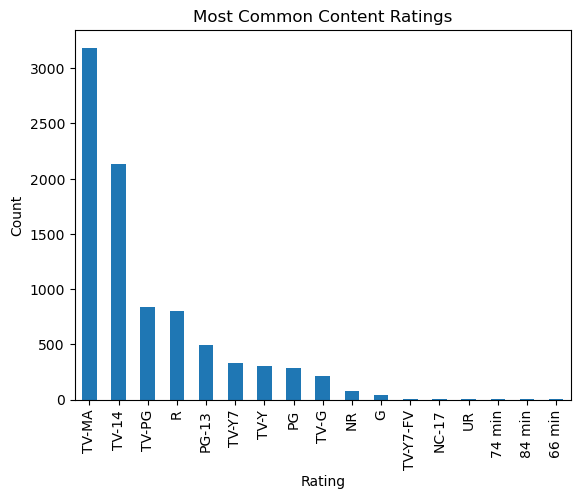

In [59]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Most Common Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

- TV-MA is the most common content rating  
- TV-14 is the second most frequent rating  
- Majority of content targets mature audience  
- Ratings like TV-PG and R have moderate presence  
- Kids-focused ratings are less common  
- Very few contents fall under rare ratings  
- Overall distribution is skewed towards higher age ratings  

***11.Genre Trends***

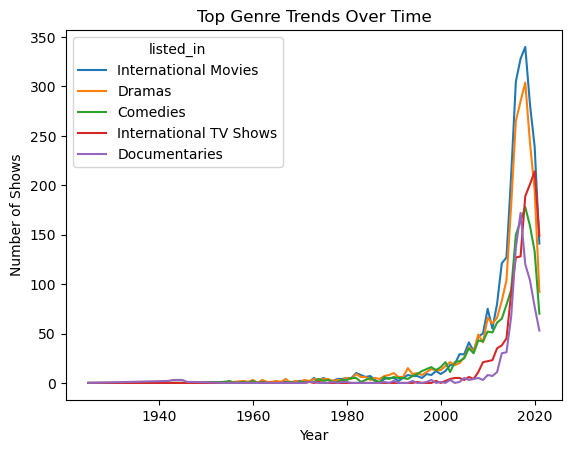

In [60]:
df_genre = df.copy()
df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('listed_in')
genre_trend = df_genre.groupby(['release_year', 'listed_in']).size().unstack().fillna(0)
top_genres = df_genre['listed_in'].value_counts().head(5).index
genre_trend[top_genres].plot()
plt.title("Top Genre Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

- All top genres show growth over time  
- Rapid increase observed after 2010  
- International Movies have the highest growth  
- Dramas and Comedies also show strong upward trends  
- International TV Shows increased significantly in recent years  
- Documentaries show steady but slower growth  
- Peak observed around recent years followed by slight decline  

***12.Geographical Analysis***

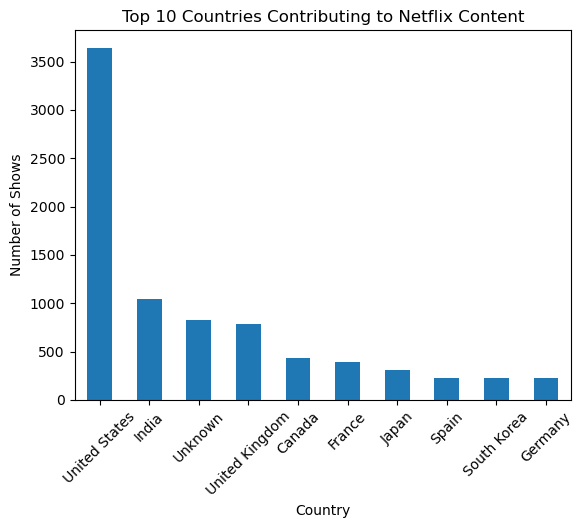

In [61]:
df_country = df.copy()
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')
country_counts = df_country['country'].value_counts().head(10)
country_counts.plot(kind='bar')
plt.title("Top 10 Countries Contributing to Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()

- United States contributes the highest content  
- India is the second-largest contributor  
- United Kingdom also has significant contribution  
- “Unknown” category shows noticeable count  
- Countries like Canada and France have moderate presence  
- Japan, Spain, South Korea, and Germany contribute less  
- Content contribution is concentrated among few countries  

***13.Correlation Analysis***

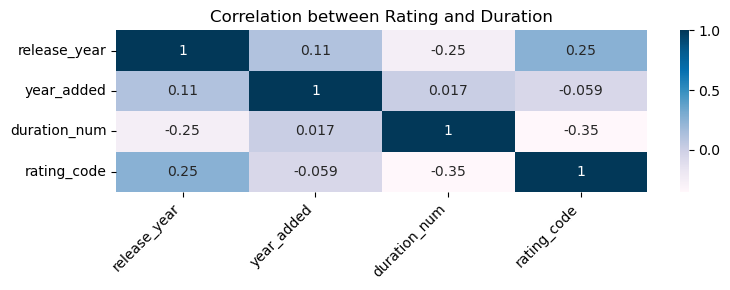

In [79]:
plt.figure(figsize=(8,3))  
sns.heatmap(corr, annot=True, cmap='PuBu')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation between Rating and Duration")
plt.tight_layout() 
plt.show()

- Most correlations are weak (values close to 0)  
- Release year and rating show slight positive correlation  
- Duration has a negative correlation with rating  
- Year added has almost no correlation with duration  
- No strong relationship between variables observed  
- Indicates variables are mostly independent  
- No significant multicollinearity in the dataset  

***14.Audience Engagement Part-1***

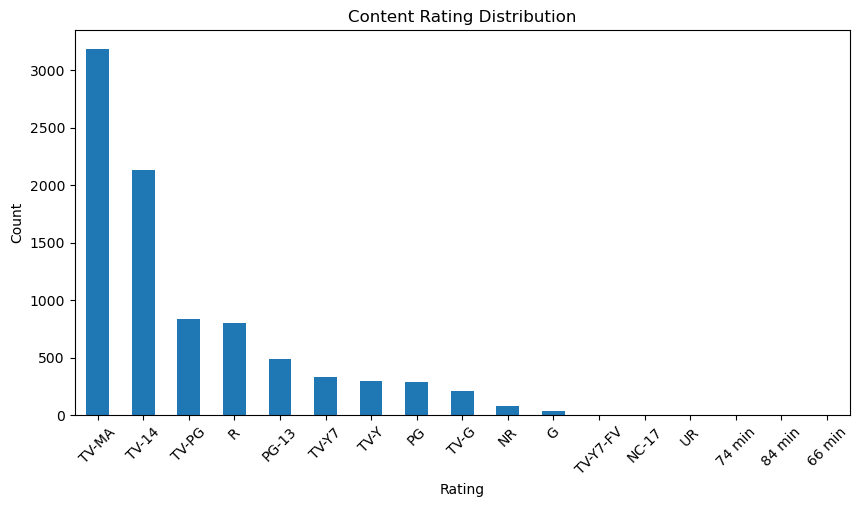

In [83]:
ratings = df['rating'].value_counts()
plt.figure(figsize=(10,5))
ratings.plot(kind='bar')
plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- TV-MA has the highest content count  
- TV-14 is the second most common rating  
- Majority content is targeted towards mature audience  
- Ratings like TV-PG and R have moderate presence  
- Kids ratings (TV-Y, TV-Y7, G) are less frequent  
- Very few contents fall under rare ratings  
- Distribution is skewed towards higher age ratings  

***15.Audience Engagement Part-2***

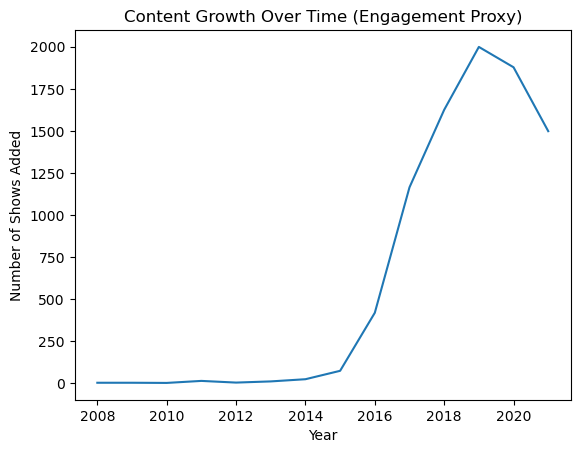

In [85]:
engagement_proxy = df['year_added'].value_counts().sort_index()
engagement_proxy.plot()
plt.title("Content Growth Over Time (Engagement Proxy)")
plt.xlabel("Year")
plt.ylabel("Number of Shows Added")
plt.show()

- Content addition increases significantly over time  
- Very slow growth before 2015  
- Rapid rise observed after 2016  
- Peak content addition around 2019  
- Slight decline in recent years  
- Indicates strong growth in user engagement  
- Overall upward trend in content expansion  

***16.Content Variety***

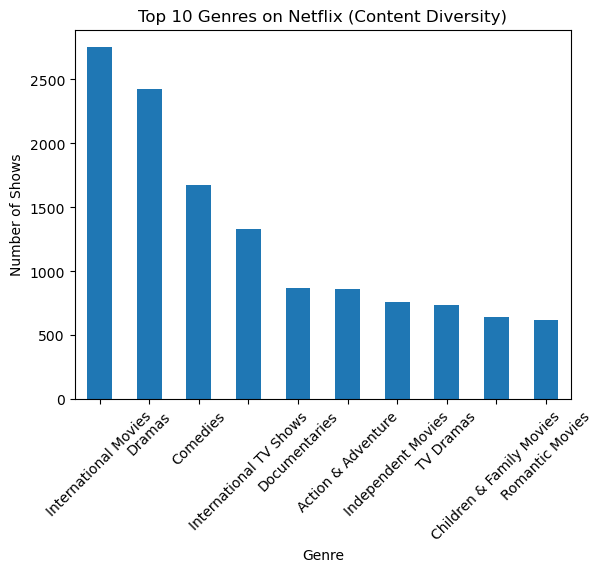

In [87]:
df_genre = df.copy()
df_genre['listed_in'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('listed_in')
genre_counts = df_genre['listed_in'].value_counts()
genre_counts.head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix (Content Diversity)")
plt.xlabel("Genre")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()

- International Movies have the highest count  
- Dramas and Comedies are highly popular genres  
- International TV Shows also have strong presence  
- Documentaries and Action & Adventure have moderate counts  
- Independent Movies and TV Dramas show steady contribution  
- Children & Family Movies and Romantic Movies are less frequent  
- Indicates a mix of global and popular mainstream content  

***17.Language Analysis***

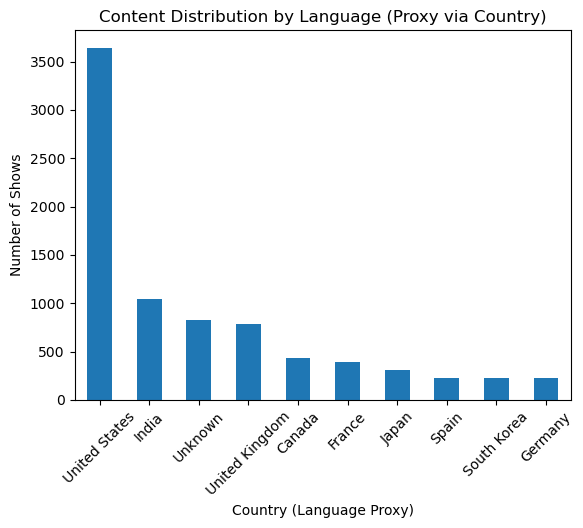

In [88]:
df_lang = df.copy()
df_lang['country'] = df_lang['country'].str.split(', ')
df_lang = df_lang.explode('country')
lang_counts = df_lang['country'].value_counts().head(10)
lang_counts.plot(kind='bar')
plt.title("Content Distribution by Language (Proxy via Country)")
plt.xlabel("Country (Language Proxy)")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()

- United States dominates content distribution  
- India is the second-largest contributor  
- United Kingdom also shows strong presence  
- “Unknown” category has noticeable count  
- Countries like Canada and France have moderate contribution  
- Japan, Spain, South Korea, and Germany contribute less  
- Content is heavily concentrated in a few major regions  

***18.Current Evolution Over Time***

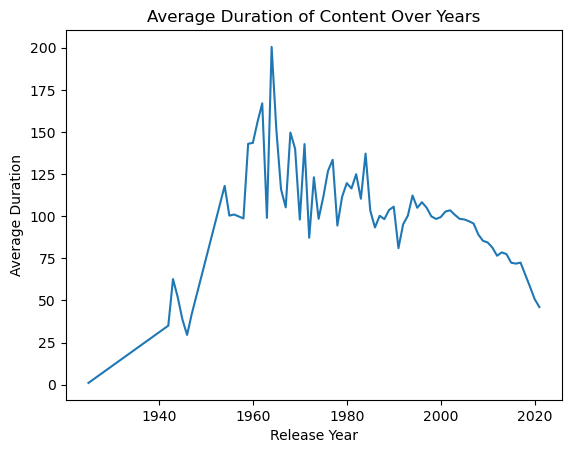

In [91]:
duration_trend = df.groupby('release_year')['duration_num'].mean()
duration_trend.plot()
plt.title("Average Duration of Content Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Duration")
plt.show()

- Average duration increases initially over the years  
- Peak duration observed around 1960s  
- High fluctuations in duration during mid years  
- Gradual stabilization after 1980  
- Slight decline in recent years  
- Recent content has shorter average duration  
- Indicates shift towards shorter content formats  

***19.User Preferences***

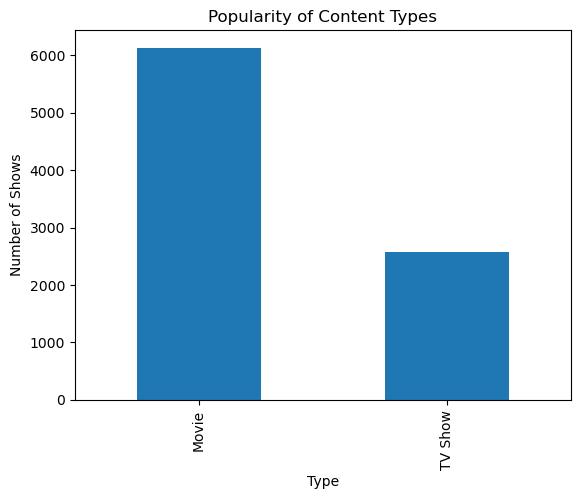

In [93]:
type_counts = df['type'].value_counts()
type_counts.plot(kind='bar')
plt.title("Popularity of Content Types")
plt.xlabel("Type")
plt.ylabel("Number of Shows")
plt.show()

- Movies have significantly higher count than TV Shows  
- Movies dominate the Netflix content library  
- TV Shows form a smaller portion of total content  
- Indicates stronger focus on movie-based content  
- Content type distribution is highly imbalanced  
- Suggests user preference leans more towards movies  

***20.Conclusions and Recommendations***

##  Conclusion (Key Findings)

- **Movies dominate the platform**  
  Netflix contains more Movies than TV Shows, indicating a stronger focus on film-based content.

- **Rapid growth after 2015**  
  There has been a significant increase in content release after 2015, showing strong platform expansion.

- **Popular genres: Drama & Comedy**  
  These genres are the most common, suggesting high audience preference and production focus.

- **Majority content is TV-MA rated**  
  This indicates that Netflix mainly targets a mature audience group.

- **Geographical dominance of the USA**  
  The United States contributes the most content, followed by India and the UK, showing global presence with regional dominance.

- **Standard duration pattern**  
  Most movies fall within the 80–120 minutes range, aligning with common viewing preferences.

- **No strong correlation between rating & duration**  
  Content length does not significantly depend on its rating category.

- **Use of proxy metrics for popularity**  
  Due to lack of user data (views, reviews), content distribution was used to estimate popularity.

## Recommendations

- **Increase global content diversity**  
  Invest more in underrepresented countries to attract a broader audience.

- **Expand genre variety**  
  Focus on less explored genres to cater to niche audiences.

- **Balance content ratings**  
  Include more family-friendly and youth-oriented content.

- **Leverage popular genres strategically**  
  Continue focusing on Drama and Comedy while experimenting with new formats.

- **Use user engagement data in future**  
  Incorporate metrics like watch time and reviews for deeper insights.
